In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.spatial import Voronoi, voronoi_plot_2d

np.random.seed(42)


## What is a Poisson Random Measure?

A *Poisson Random Measure (PRM)* generalizes the Poisson process from the line $\mathbb{R}_+$ to an arbitrary measurable space $(E, \mathcal{E})$.
Let $\mu$ be a $\sigma$-finite measure on $(E, \mathcal{E})$ called the mean measure (or intensity measure). A random measure $N$ is a Poisson random measure with mean measure $\mu$ if:
1. For every Borel set $A \in \mathcal{E}$, the random variable $N(A)$ is Poisson-distributed:

$N(A) \sim Poisson(\mu(A))$

2. For disjoint sets $A_1, A_2, \dots, A_n$, the random variables $N(A_1), N(A_2), \dots, N(A_n)$ are independent.
3. The measure can be written as a sum of Dirac masses at random points:

$N\ = \displaystyle\sum_{i} \delta_{X_i}$

where $\{X_i\}$ are the random atoms of the measure in $E$.

$\Sigma{0}{10}$

### Key examples:
 
- *Poisson process* on $\mathbb{R}_+: E = \mathbb{R}_+, \mu(A) = \lambda |A|$
- *Poisson point process* in $\mathbb{R}^2: E = \mathbb{R}^2, \mu(A) = \displaystyle\int_A \lambda(x,y)\,dx\,dy$
- *Compound Poisson process*: $E = \mathbb{R}_+ \times \mathbb{R}$, atoms are $(T_i, Y_i)$ with marks $Y_i$

## 1D Homogeneous Poisson Process

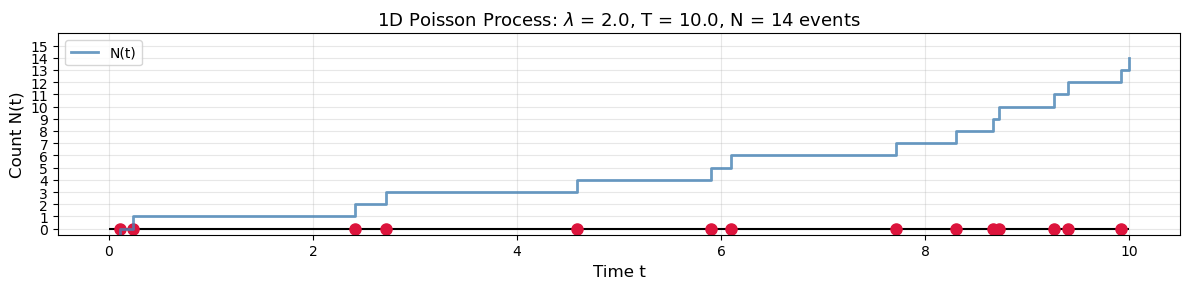

In [14]:
lambda_rate = 2.0
T = 10.0

N = np.random.poisson(lambda_rate * T)
times = np.sort(np.random.uniform(0, T, N))

fig, ax = plt.subplots(figsize=(12, 3))

ax.hlines(0, 0, T, colors='black', linewidth=1.5)
for t in times:
    ax.vlines(t, -0.15, 0.15, colors='crimson', linewidth=2)
    ax.plot(t, 0, 'o', color='crimson', markersize=8)

step_times = np.concatenate([[0], times, [T]])
step_values = np.arange(len(step_times))
ax.step(step_times, step_values - 1, where='post', color='steelblue', 
        linewidth=2, label='N(t)', alpha=0.8)

ax.set_xlim(-0.5, T + 0.5)
ax.set_ylim(-0.5, N + 2)
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Count N(t)', fontsize=12)
ax.set_title(rf'1D Poisson Process: $\lambda$ = {lambda_rate}, T = {T}, N = {N} events', fontsize=13)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_yticks(range(0, N + 2))

plt.tight_layout()
plt.show()

## 2D Spatial Poisson Point Process
When $E = \mathbb{R}^2$ (or a bounded region), the PRM becomes a Poisson point process. For a homogeneous process with constant intensity $\lambda$ on a region of area $|A|$:

Points are i.i.d. uniform in the region, and the number of points is Poisson-distributed.

## 2D Homogeneous Poisson Point Process

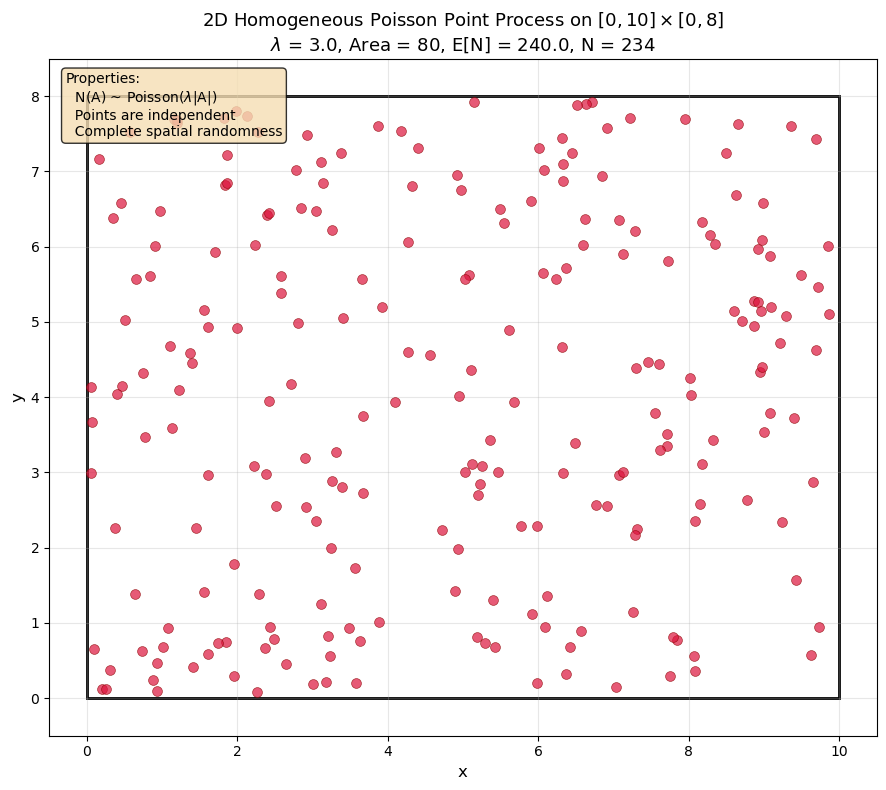

In [15]:
np.random.seed(42)

W, H = 10, 8
lambda_2d = 3.0

area = W * H
N_2d = np.random.poisson(lambda_2d * area)

x = np.random.uniform(0, W, N_2d)
y = np.random.uniform(0, H, N_2d)

fig, ax = plt.subplots(figsize=(10, 8))

rect = plt.Rectangle((0, 0), W, H, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(rect)

ax.scatter(x, y, c='crimson', s=50, alpha=0.7, edgecolors='darkred', linewidth=0.5, zorder=3)

ax.set_xlim(-0.5, W + 0.5)
ax.set_ylim(-0.5, H + 0.5)
ax.set_aspect('equal')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)

title_str = (rf'2D Homogeneous Poisson Point Process on $[0,{W}] \times [0,{H}]$' + '\n' +
             rf'$\lambda$ = {lambda_2d}, Area = {area}, E[N] = {lambda_2d * area}, N = {N_2d}')
ax.set_title(title_str, fontsize=13)

ax.grid(True, alpha=0.3)

textstr = (rf'Properties:' + '\n' +
           rf'  N(A) ~ Poisson($\lambda$|A|)' + '\n' +
           rf'  Points are independent' + '\n' +
           rf'  Complete spatial randomness')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()


## Inhomogeneous Poisson Process
If the intensity is not constant but a function $\lambda(t)$ or $\lambda(x,y)$, we have an inhomogeneous Poisson random measure. The mean measure is:

$\mu(A) = \displaystyle\int_{A} \lambda(z)dz$

Simulation is typically done by thinning: simulate a homogeneous process with intensity $\lambda_{\max} \geq \sup \lambda(z)$, then keep each point $z$ with probability $\lambda(z)/\lambda_{\max}$.

## 1D Inhomogeneous Poisson Process

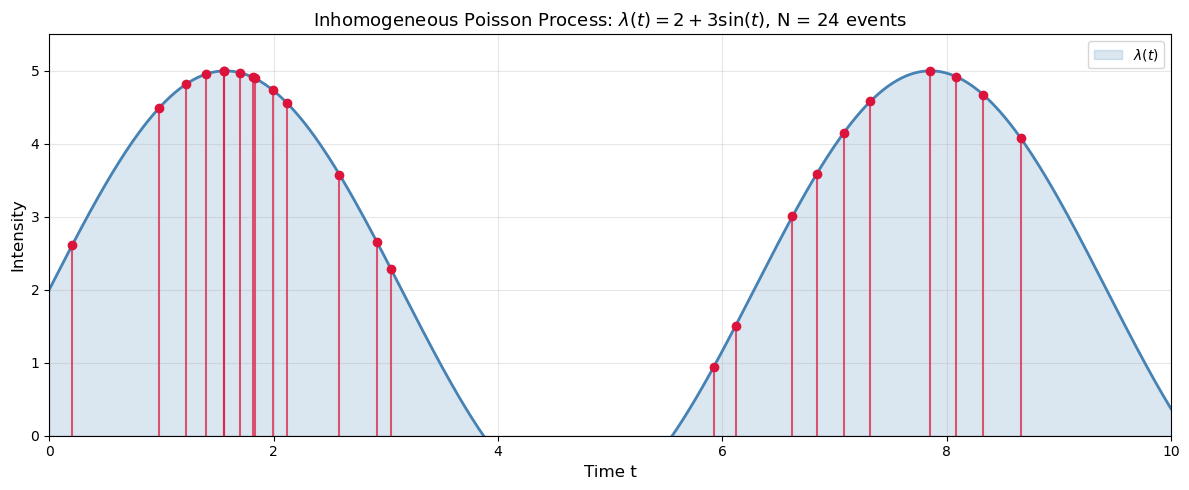

In [16]:
np.random.seed(42)

T = 10.0

def lambda_func(t):
    return 2.0 + 3.0 * np.sin(t)

lambda_max = 5.0

N_hom = np.random.poisson(lambda_max * T)
t_hom = np.sort(np.random.uniform(0, T, N_hom))

u = np.random.uniform(0, 1, N_hom)
keep = u <= lambda_func(t_hom) / lambda_max
t_inhom = t_hom[keep]
N_inhom = len(t_inhom)

t_fine = np.linspace(0, T, 500)
intensity_curve = lambda_func(t_fine)

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(t_fine, 0, intensity_curve, alpha=0.2, color='steelblue', label=rf'$\lambda(t)$')
ax.plot(t_fine, intensity_curve, color='steelblue', linewidth=2)

for t in t_inhom:
    ax.vlines(t, 0, lambda_func(t), colors='crimson', linewidth=1.5, alpha=0.7)
    ax.plot(t, lambda_func(t), 'o', color='crimson', markersize=6)

ax.set_xlim(0, T)
ax.set_ylim(0, lambda_max + 0.5)
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Intensity', fontsize=12)
ax.set_title(rf'Inhomogeneous Poisson Process: $\lambda(t) = 2 + 3\sin(t)$, N = {N_inhom} events', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## PRM on Product Spaces — Compound Poisson Processes
A compound Poisson process is exactly a Poisson random measure on the product space $E = \mathbb{R}_+ \times \mathbb{R}$. Each atom is a pair $(T_i, Y_i)$ where:
 
- $T_i$ is the arrival time (Poisson process on $\mathbb{R}_+$)
- $Y_i$ is the mark (jump size) at that time
The random measure is:

$ N = \displaystyle\sum_{i} \sigma_{(T_i,Y_i)}$

and the compound process is the integral:

$X_(t) = \displaystyle\int_{[0,t] \times \mathbb{R}} y\ N(ds,dy)\ =\ \displaystyle\sum_{T_i \leq t}Y_i$

## Compound Poisson Process (PRM on \mathbb{R}_+ \times \mathbb{R})

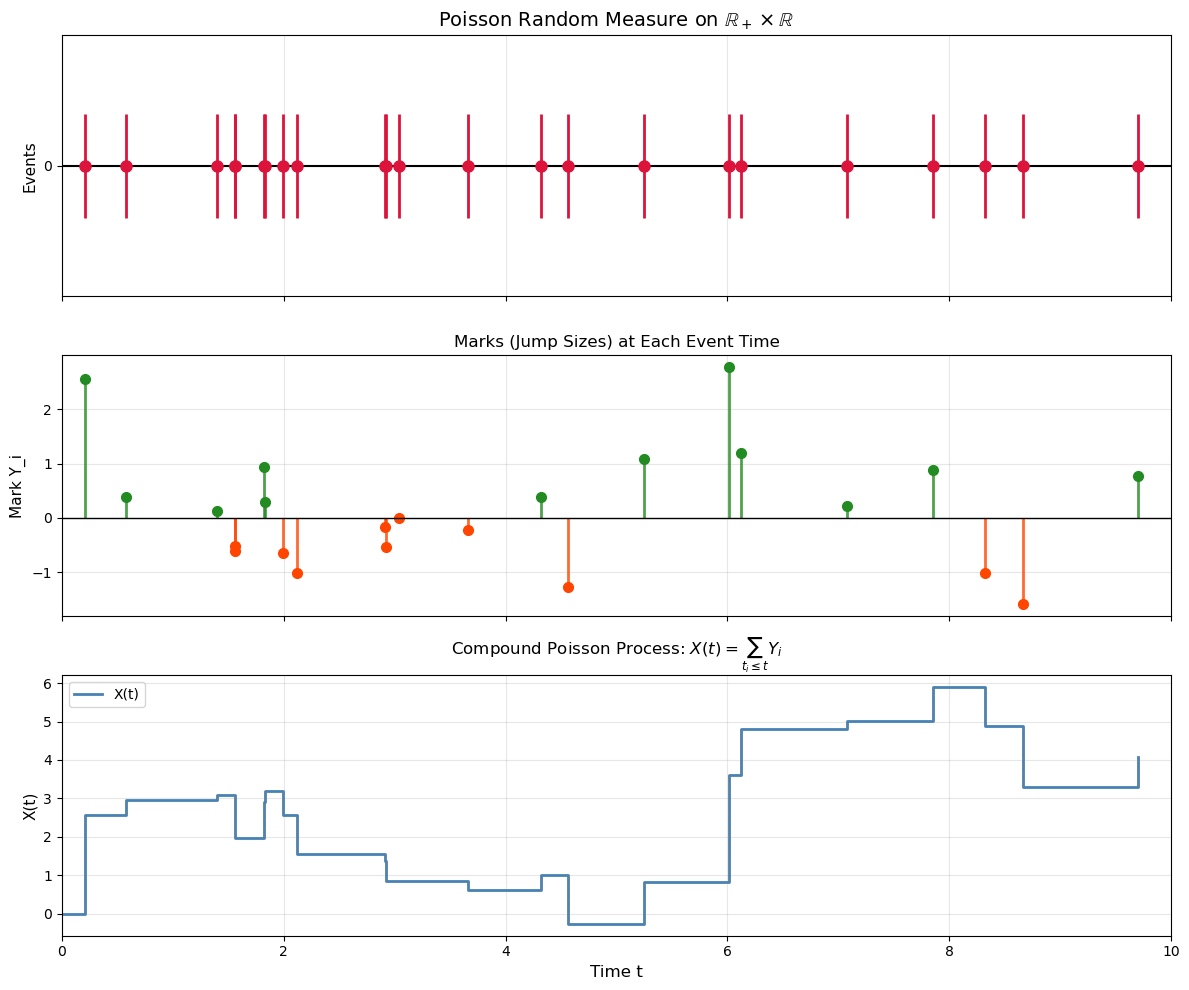

In [17]:
np.random.seed(42)

lambda_rate = 2.0
T = 10.0

N = np.random.poisson(lambda_rate * T)
times = np.sort(np.random.uniform(0, T, N))

marks = np.random.normal(0, 1, N)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax1 = axes[0]
ax1.hlines(0, 0, T, colors='black', linewidth=1.5)
for t in times:
    ax1.vlines(t, -0.2, 0.2, colors='crimson', linewidth=2)
    ax1.plot(t, 0, 'o', color='crimson', markersize=8)
ax1.set_ylim(-0.5, 0.5)
ax1.set_yticks([0])
ax1.set_ylabel('Events', fontsize=11)
ax1.set_title(rf'Poisson Random Measure on $\mathbb{{R}}_+ \times \mathbb{{R}}$', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for i, t in enumerate(times):
    color = 'forestgreen' if marks[i] >= 0 else 'orangered'
    ax2.vlines(t, 0, marks[i], colors=color, linewidth=2, alpha=0.8)
    ax2.plot(t, marks[i], 'o', color=color, markersize=7)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel('Mark Y_i', fontsize=11)
ax2.set_title('Marks (Jump Sizes) at Each Event Time', fontsize=12)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
cumsum_marks = np.cumsum(marks)
step_times = np.concatenate([[0], times, [T]])
step_values = np.concatenate([[0], cumsum_marks])
ax3.step(step_times[:-1], step_values, where='post', color='steelblue', linewidth=2, label='X(t)')
for i, t in enumerate(times):
    y_before = cumsum_marks[i] - marks[i] if i > 0 else 0
    y_after = cumsum_marks[i]
    ax3.vlines(t, y_before, y_after, colors='gray', linewidth=1, alpha=0.5, linestyle='--')

ax3.set_xlabel('Time t', fontsize=12)
ax3.set_ylabel('X(t)', fontsize=11)
ax3.set_title(rf'Compound Poisson Process: $X(t) = \sum_{{t_i \leq t}} Y_i$', fontsize=12)
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, T)

plt.tight_layout()
plt.show()


## 2D Inhomogeneous Poisson Process with Intensity Heatmap

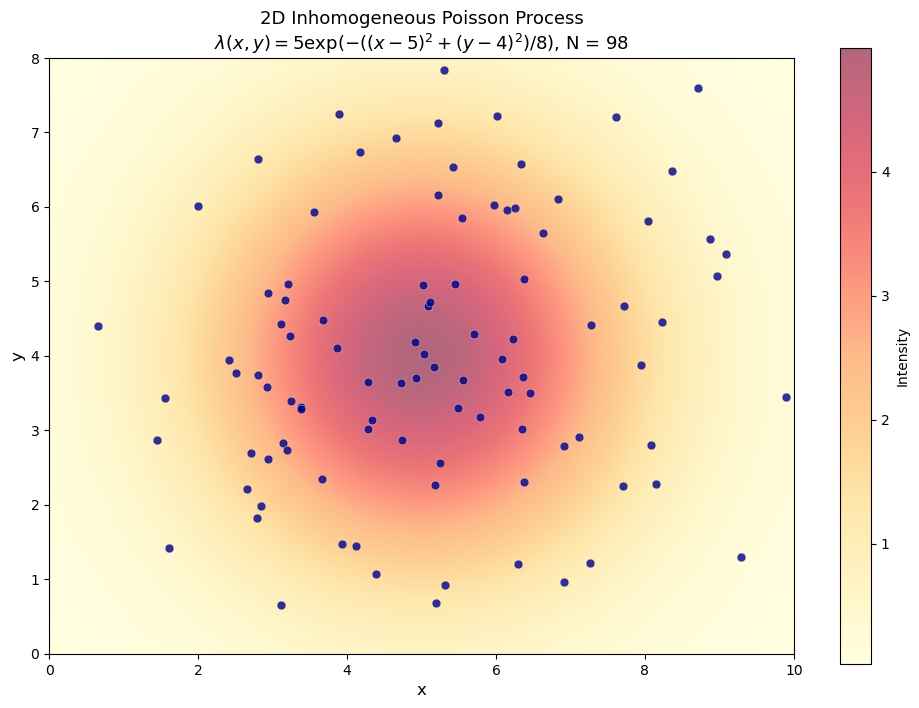

In [18]:
np.random.seed(42)

W, H = 10, 8

def lambda_2d_func(x, y):
    return 5.0 * np.exp(-((x - 5)**2 + (y - 4)**2) / 8.0)

x_grid = np.linspace(0, W, 200)
y_grid = np.linspace(0, H, 200)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z = lambda_2d_func(X_grid, Y_grid)

lambda_max_2d = np.max(Z)

N_hom_2d = np.random.poisson(lambda_max_2d * W * H)
x_hom = np.random.uniform(0, W, N_hom_2d)
y_hom = np.random.uniform(0, H, N_hom_2d)

u_2d = np.random.uniform(0, 1, N_hom_2d)
keep_2d = u_2d <= lambda_2d_func(x_hom, y_hom) / lambda_max_2d
x_inhom = x_hom[keep_2d]
y_inhom = y_hom[keep_2d]
N_inhom = len(x_inhom)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(Z, extent=[0, W, 0, H], origin='lower', cmap='YlOrRd', alpha=0.6)
plt.colorbar(im, ax=ax, label='Intensity', shrink=0.8)

ax.scatter(x_inhom, y_inhom, c='navy', s=40, alpha=0.8, edgecolors='white', linewidth=0.3, zorder=3)

ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect('equal')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)

title_str = (rf'2D Inhomogeneous Poisson Process' + '\n' +
             rf'$\lambda(x,y) = 5 \exp(-((x-5)^2 + (y-4)^2)/8)$, N = {N_inhom}')
ax.set_title(title_str, fontsize=13)

plt.tight_layout()
plt.show()


### Visualizing the PRM on $\mathbb{R}_+ \times \mathbb{R}$ as a Scatter

the mesure  $N(A) = \# \{{(t_i,Y_i) \in A}\}$  counts points in Borel sets $A \subset \mathbb{{R}}_+ \times \mathbb{{R}}$

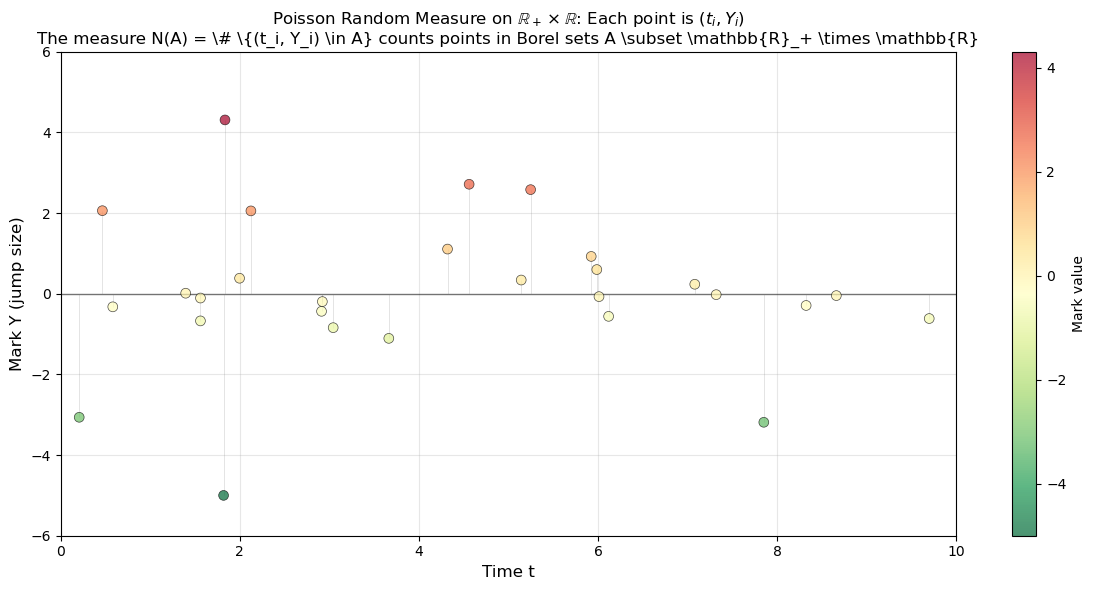

In [34]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lambda_rate = 3.0
T = 10.0

N = np.random.poisson(lambda_rate * T)
times = np.sort(np.random.uniform(0, T, N))

marks = np.random.standard_cauchy(N)
marks = np.clip(marks, -5, 5)

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(times, marks, c=marks, cmap='RdYlGn_r', s=50,
                     alpha=0.7, edgecolors='black', linewidth=0.5, zorder=3)

ax.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)

for i in range(N):
    ax.vlines(times[i], 0, marks[i], colors='gray', linewidth=0.5, alpha=0.3)

plt.colorbar(scatter, ax=ax, label='Mark value')

ax.set_xlim(0, T)
ax.set_ylim(-6, 6)
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Mark Y (jump size)', fontsize=12)

# FIXED: escaped \\# for LaTeX math mode inside rf-string
title_str = (rf'Poisson Random Measure on $\mathbb{{R}}_+ \times \mathbb{{R}}$: Each point is $(t_i, Y_i)$' + '\n' +
             rf'The measure N(A) = \# \{{(t_i, Y_i) \in A}} counts points in Borel sets A \subset \mathbb{{R}}_+ \times \mathbb{{R}}')
ax.set_title(title_str, fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Voronoi Tessellation of a 2D Poisson Point Process

The Voronoi diagram partitions the plane into regions where each region contains exactly one point and all locations in that region are closer to that point than any other. For a Poisson point process, this reveals the "territory" of each random atom.

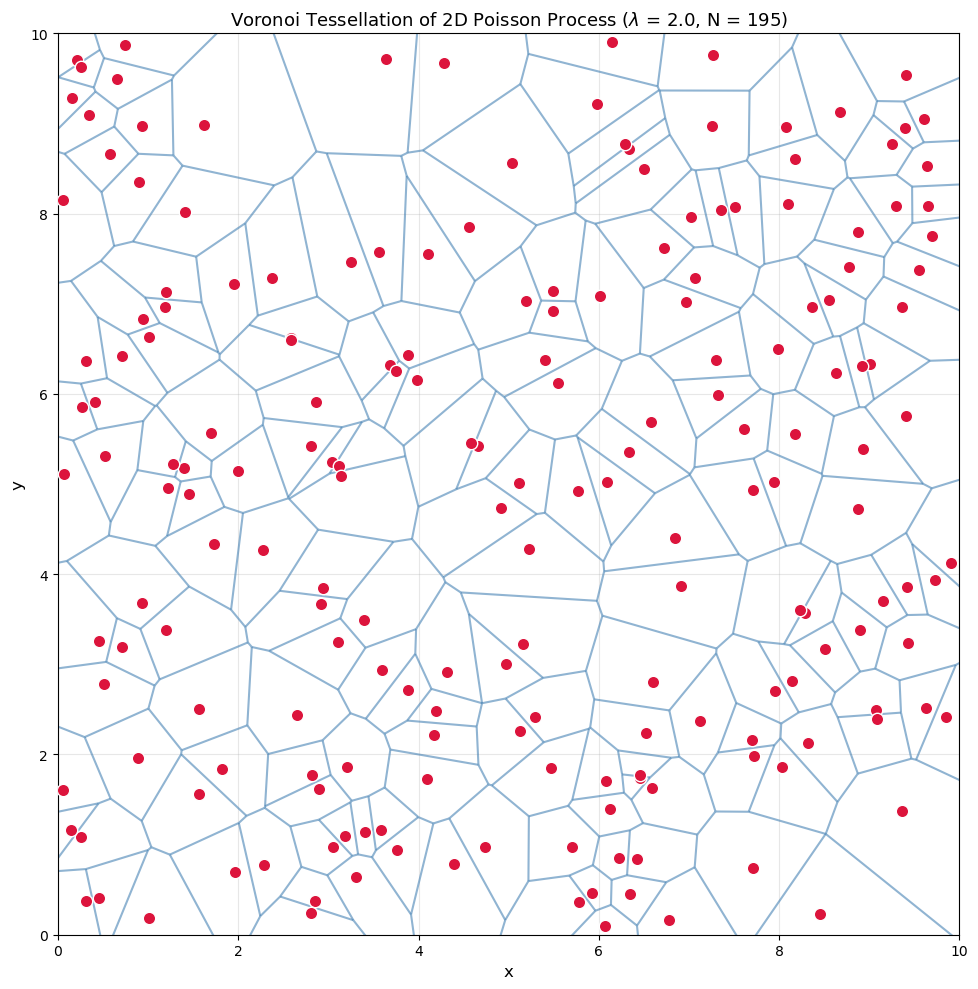

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d  # FIXED: added imports

np.random.seed(42)

W, H = 10, 10
lambda_v = 2.0

area = W * H
N_v = np.random.poisson(lambda_v * area)

points = np.random.uniform(0, W, (N_v, 2))
points[:, 1] *= H / W

# Add boundary points so Voronoi regions extend to edges
boundary_points = np.array([
    [-10, -10], [-10, 20], [20, -10], [20, 20],
    [5, -10], [5, 20], [-10, 5], [20, 5]
])
all_points = np.vstack([points, boundary_points])

vor = Voronoi(all_points)

fig, ax = plt.subplots(figsize=(10, 10))

voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='steelblue',
                line_alpha=0.6, line_width=1.5, point_size=0)

ax.scatter(points[:, 0], points[:, 1], c='crimson', s=80, zorder=3,
           edgecolors='white', linewidth=1)

ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect('equal')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title(rf'Voronoi Tessellation of 2D Poisson Process ($\lambda$ = {lambda_v}, N = {N_v})', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Mean Measure and Numerical Integration

The *mean measure* $\mu(A) = \mathbb{E}[N(A)]$ is the deterministic counterpart of the random measure. For an inhomogeneous process, we can verify that the empirical count matches the theoretical mean measure.


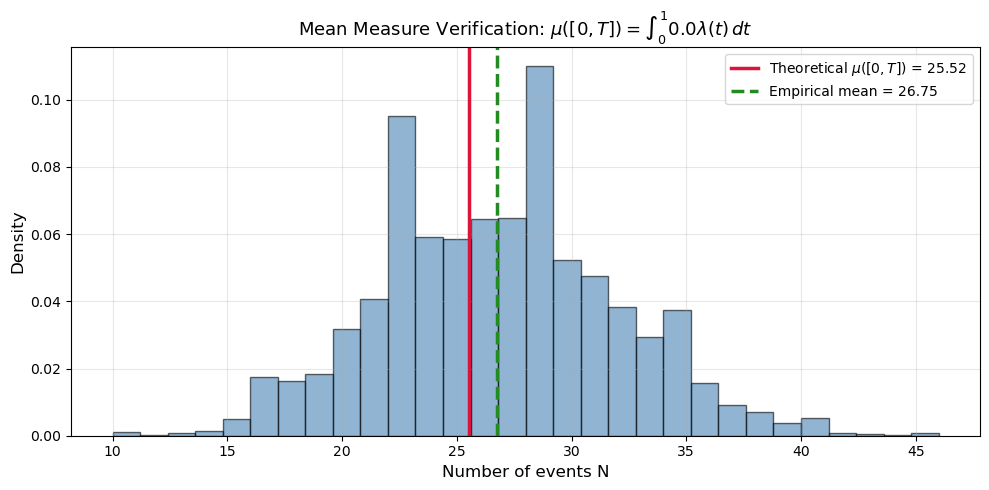

Theoretical mean measure: 25.517
Empirical average count:   26.751


In [21]:
np.random.seed(42)

T = 10.0

def lambda_t(t):
    return 2.0 + 3.0 * np.sin(t)

# Theoretical mean measure on [0, T]
t_fine = np.linspace(0, T, 1000)
mean_measure_theory = np.trapezoid(lambda_t(t_fine), t_fine)

# Empirical: simulate many times and average the count
n_sims = 5000
counts = []
lambda_max = 5.0

for _ in range(n_sims):
    N_hom = np.random.poisson(lambda_max * T)
    t_hom = np.random.uniform(0, T, N_hom)
    u = np.random.uniform(0, 1, N_hom)
    keep = u <= lambda_t(t_hom) / lambda_max
    counts.append(np.sum(keep))

mean_empirical = np.mean(counts)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(counts, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='black')
ax.axvline(mean_measure_theory, color='crimson', linewidth=2.5, 
           label=rf'Theoretical $\mu([0,T])$ = {mean_measure_theory:.2f}')
ax.axvline(mean_empirical, color='forestgreen', linewidth=2.5, linestyle='--',
           label=rf'Empirical mean = {mean_empirical:.2f}')

ax.set_xlabel('Number of events N', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(rf'Mean Measure Verification: $\mu([0,T]) = \int_0^{T} \lambda(t)\,dt$', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(rf"Theoretical mean measure: {mean_measure_theory:.3f}")
print(rf"Empirical average count:   {mean_empirical:.3f}")


## Summary

|  Concept  |  Space E  |  Mean Measure \mu(A)  |  Visualization  |
|-----------|-----------|-----------------------|-----------------|
|  Poisson process  |  \mathbb{R}+  |  \lambda \|A\|  |  Timeline + counting process  |
|  Spatial process  |  \mathbb{R}^2  |  \lambda \|A\|  |  Scatter plot  |
|  Inhomogeneous  |  \mathbb{R}+ or \mathbb{R}^2  |  \int_A \lambda(z)dz  |  Intensity heatmap + thinned points  |
|  Compound / Marked  |  \mathbb{R}+ \times \mathbb{R}  |  \lambda ds \times F(dy)  |  Product space scatter  |
|  Voronoi  |  \mathbb{R}^2  |  \lambda \|A\|  |  Tessellation regions  |


### The Poisson Random Measure is the foundation for:
 
- Lévy processes (via the Lévy-Itô decomposition)
- Spatial statistics (Cox processes, cluster processes)
- Queueing theory and risk theory
- Stochastic partial differential equations (Poisson noise)